<a href="https://colab.research.google.com/github/77marco/Challenge-TelecomX-1-DataScience/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [13]:
import pandas as pd

# Esta es la URL "Raw" que obtuviste
url_raw = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Extraemos los datos
df_telecom = pd.read_json(url_raw)

# Mostramos los primeros datos para confirmar
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [14]:
import pandas as pd

# 1. "Aplanamos" los diccionarios JSON en columnas independientes
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# 2. Unimos todo en un solo DataFrame 'limpio'
# Concatenamos customerID y Churn con las nuevas columnas creadas
df_telecom_final = pd.concat([df_telecom[['customerID', 'Churn']],
                             df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Verificamos la estructura y tipos de datos
print("Resumen del nuevo conjunto de datos:")
df_telecom_final.info()

# Mostramos las primeras filas para confirmar que ya no hay llaves {}
df_telecom_final.head()

Resumen del nuevo conjunto de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contr

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [15]:
# 1. Convertimos Charges.Total a numérico.
# 'errors=coerce' transformará cualquier espacio vacío en NaN (nulo) para que no falle.
df_telecom_final['Charges.Total'] = pd.to_numeric(df_telecom_final['Charges.Total'], errors='coerce')

# 2. Verificamos si aparecieron nulos tras la conversión
print(f"Nulos en Charges.Total: {df_telecom_final['Charges.Total'].isnull().sum()}")

# 3. Si hay nulos, los llenamos con 0 o con el valor de Monthly (depende de tu criterio)
df_telecom_final['Charges.Total'] = df_telecom_final['Charges.Total'].fillna(0)

# 4. Verificamos tipos finales
df_telecom_final.dtypes[['Charges.Monthly', 'Charges.Total']]

Nulos en Charges.Total: 11


,0
Charges.Monthly,float64
Charges.Total,float64


In [16]:
# 1. Verificamos si hay filas duplicadas
duplicados = df_telecom_final.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

# 2. Verificamos los valores únicos en la columna objetivo (Churn)
# para asegurar que no haya errores de escritura
print(f"Valores únicos en Churn: {df_telecom_final['Churn'].unique()}")

# 3. Revisamos consistencia en una categoría clave como 'InternetService'
print(f"Categorías en InternetService: {df_telecom_final['InternetService'].unique()}")

Registros duplicados: 0
Valores únicos en Churn: ['No' 'Yes' '']
Categorías en InternetService: ['DSL' 'Fiber optic' 'No']


In [17]:
# 1. Contamos cuántos registros tienen el campo Churn vacío
vacios_churn = (df_telecom_final['Churn'] == '').sum()
print(f"Registros con Churn vacío: {vacios_churn}")

# 2. Nos quedamos solo con los registros que SÍ tienen 'Yes' o 'No'
df_telecom_final = df_telecom_final[df_telecom_final['Churn'] != '']

# 3. Verificamos que ya no existan
print(f"Nuevos valores únicos en Churn: {df_telecom_final['Churn'].unique()}")
print(f"Tamaño final del dataset: {df_telecom_final.shape}")

Registros con Churn vacío: 224
Nuevos valores únicos en Churn: ['No' 'Yes']
Tamaño final del dataset: (7043, 21)


In [18]:
# 1. Identificamos las columnas que son de tipo 'object' (texto)
columnas_texto = df_telecom_final.select_dtypes(include=['object']).columns

# 2. Eliminamos espacios en blanco al inicio o final y estandarizamos
for col in columnas_texto:
    # Quitamos espacios extra y aseguramos un formato consistente
    df_telecom_final[col] = df_telecom_final[col].str.strip()

# 3. Verificamos si hay alguna columna con valores que necesiten reemplazo
# Por ejemplo, a veces 'No internet service' se puede simplificar a 'No'
df_telecom_final = df_telecom_final.replace('No internet service', 'No')
df_telecom_final = df_telecom_final.replace('No phone service', 'No')

# 4. Comprobamos los cambios en una columna de ejemplo
print("Valores estandarizados en OnlineSecurity:", df_telecom_final['OnlineSecurity'].unique())

Valores estandarizados en OnlineSecurity: ['No' 'Yes']


In [19]:
# 1. Creamos la nueva columna 'Cuentas_Diarias'
# Dividimos el cargo mensual por 30 días
df_telecom_final['Cuentas_Diarias'] = (df_telecom_final['Charges.Monthly'] / 30).round(2)

# 2. Reubicamos la columna al lado de Charges.Monthly para que sea fácil comparar
# (Opcional: solo para orden visual en el .head())
cols = list(df_telecom_final.columns)
# Insertamos la nueva columna antes de Charges.Total
df_telecom_final = df_telecom_final[cols[:-2] + [cols[-1]] + [cols[-2]]]

# 3. Visualizamos el resultado
df_telecom_final[['Charges.Monthly', 'Cuentas_Diarias']].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [20]:
# 1. Creamos un diccionario para mapear los valores de texto a binarios
mapeo = {'Yes': 1, 'No': 0}

# 2. Aplicamos la transformación a la columna objetivo (Churn)
# y a otras columnas binarias importantes
columnas_a_transformar = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in columnas_a_transformar:
    df_telecom_final[col] = df_telecom_final[col].map(mapeo)

# 3. Renombramos columnas para mayor claridad (Traducimos si es necesario)
# Ejemplo: cambiar Churn por Evasion o dejarlo más limpio
df_telecom_final = df_telecom_final.rename(columns={
    'Churn': 'Evasion',
    'tenure': 'Meses_Contrato',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales'
})

# 4. Verificamos los cambios
df_telecom_final[['Evasion', 'Meses_Contrato', 'Cargos_Mensuales']].head()

,Evasion,Meses_Contrato,Cargos_Mensuales
0,0,9,65.6
1,0,9,59.9
2,1,4,73.9
3,1,13,98.0
4,1,3,83.9


#📊 Carga y análisis

### Análisis Descriptivo

In [21]:
# 1. Generamos el análisis descriptivo de las variables numéricas
analisis_numerico = df_telecom_final.describe().round(2)

# 2. Calculamos la mediana por separado (ya que el método de Pandas .describe() no la incluye por defecto)
mediana = df_telecom_final.select_dtypes(include=['number']).median()

# 3. Mostramos los resultados principales
print("Resumen Estadístico de las Variables Numéricas:")
display(analisis_numerico)

print("\nMedianas de las variables:")
print(mediana)

Resumen Estadístico de las Variables Numéricas:


,Evasion,SeniorCitizen,Partner,Dependents,Meses_Contrato,PhoneService,PaperlessBilling,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00
mean,0.27,0.16,0.48,0.30,32.37,0.9,0.59,64.76,2.16,2279.73
std,0.44,0.37,0.50,0.46,24.56,0.3,0.49,30.09,1.00,2266.79
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,18.25,0.61,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,35.50,1.18,398.55
50%,0.00,0.00,0.00,0.00,29.00,1.0,1.00,70.35,2.34,1394.55
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,89.85,2.99,3786.60
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,118.75,3.96,8684.80



Medianas de las variables:
Evasion                0.00
SeniorCitizen          0.00
Partner                0.00
Dependents             0.00
Meses_Contrato        29.00
PhoneService           1.00
PaperlessBilling       1.00
Cargos_Mensuales      70.35
Cuentas_Diarias        2.34
Cargos_Totales      1394.55
dtype: float64


### Distribución de evasión

/tmp/ipykernel_671/4093322180.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Evasion', data=df_telecom_final, palette='viridis')


Text(0.5, 1.0, 'Proporción de Evasión')

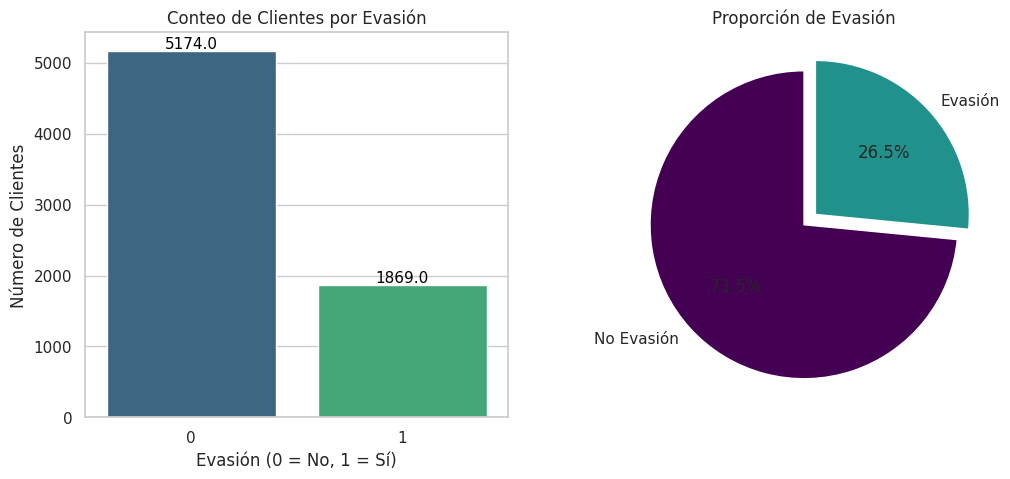

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 2. Gráfico de Barras (Conteo)
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Evasion', data=df_telecom_final, palette='viridis')
plt.title('Conteo de Clientes por Evasión')
plt.xlabel('Evasión (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# 3. Gráfico de Pastel (Proporción)
plt.subplot(1, 2, 2)
# Cambiado .pi() por .pie() y ajustado el manejo de datos
conteo_evasion = df_telecom_final['Evasion'].value_counts()
plt.pie(conteo_evasion,
        labels=['No Evasión', 'Evasión'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#440154', '#21918c'],
        explode=[0, 0.1])
plt.title('Proporción de Evasión')

### Recuento de evasión por variables categóricas

In [26]:
print(df_telecom_final.columns) # esto es para verificar los nombres exactos de mis columnas


Index(['customerID', 'Evasion', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Meses_Contrato', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Cargos_Mensuales',
       'Cuentas_Diarias', 'Cargos_Totales'],
      dtype='object')


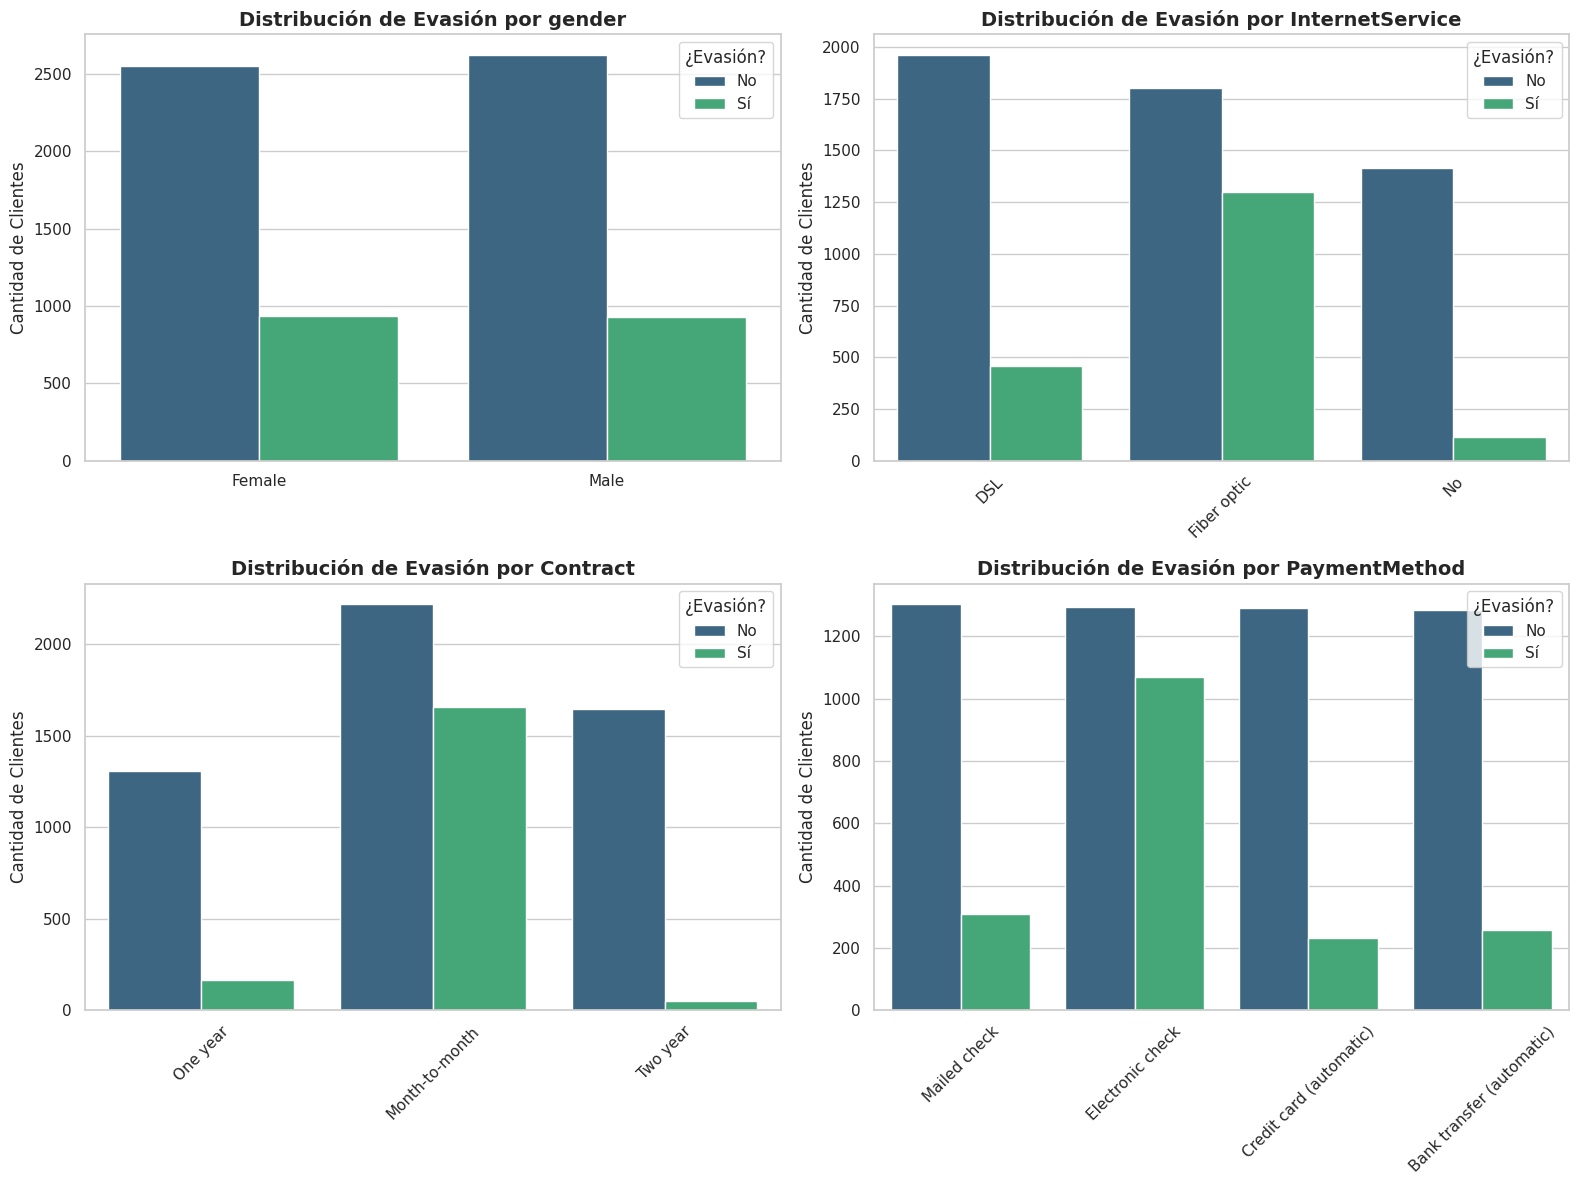

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos las variables categóricas clave (usando los nombres exactos de mi dataset)
variables_categoricas = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

# 2. Configuramos el espacio para los gráficos (2 filas y 2 columnas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flat

# 3. Creamos cada gráfico comparativo
for i, col in enumerate(variables_categoricas):
    # sns.countplot crea las barras; hue='Evasion' separa por quienes se fueron y quienes no
    sns.countplot(x=col, hue='Evasion', data=df_telecom_final, ax=axes[i], palette='viridis')

    # Personalización visual
    axes[i].set_title(f'Distribución de Evasión por {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='¿Evasión?', labels=['No', 'Sí'])

    # Rotación de etiquetas para mejorar la lectura en variables con nombres largos
    if col in ['PaymentMethod', 'Contract', 'InternetService']:
        axes[i].tick_params(axis='x', rotation=45)

# Ajustamos el diseño para que no se encimen los títulos
plt.tight_layout()
plt.show()

#📄Informe final